
# Семантический поиск по документам на старославянском из НКРЯ

В этой работе вы будете реализовывать поиск по документам на старославянском языке.  

Корпус: фрагменты из старославянского подкорпуса НКРЯ.

## Задания
Каждое домашнее задание включает 2 темы лекций. Например, это задание направлено на освоение PyTorch и работу с эмбеддингами. Обратите внимание на **вопросы и эксперименты**. Чтобы получать максимальный балл за задания, необходимо писать свои рассуждения и анализировать результы экспериментов. В таком случае оценивается не правильность ответа, а сам анализ и ход рассуждений (даже если они ошибочны). Так как задания достаточно объемные, то на их выполнение будет даваться примерно 1,5 недели. Все задания довольно beginner-friendly: в комментариях указано, что необходимо сделать.

## Как сдавать?
Готовый файл формата ipynb необходимо отправить через [форму](https://forms.gle/VXYNM6GZCbbNP22h6). Не забудьте указать фамилию в названии файла

Некоторые задания надо будет сдавать в виде ссылки на репозиторий (например, финальный проект).

Нельзя скидывать ссылку на Colab, задание в такой форме не будет принято

Если вы скидываете ссылку на GitHub, то задание будет оцениваться с учетом того, когда были внесены в него последние изменения. То есть если правки внесены после дедлайна, то отнимаются штрафные баллы.

##Оценка
Чтобы получить 7 баллов, вам достаточно сделать основную часть заданий (где вам нужно вставить части кода). Чтобы получить больше, нужно выполнить часть заданий, где весь код вы пишите самостоятельно. Эти задания примерно такой же сложности, но нужно проявить чуть больше фантазии.

Лучше сдавать задание до дедлайна, но если не вышло, то у вас есть ровно неделя после дедлайна, чтобы его сдать. Каждый день от максимального балла отнимается -1 штрафной. Если вы сдали задание через 2 дня и получили 10, то в итоге будет только 8. В последний день вы максимум можете получить 3 балла, даже если сделаете все на 10.

## Challenge
В каждом домашнем задании будет **challenge**, в котором будет предложено более глубоко погрузиться в задачу. Во-первых, это задания с повышенной сложностью: они включают работу с разными библиотеками (как в этом дз), обучение моделей, больше экспериментов. Во-вторых, за выполнение этих заданий будут отдельные бонусы. Возможные бонусы:

1.   Минимальный штраф за опоздание в течение недели: -1 балл в первую половину недели (первые 3,5 дня), -2 балла во вторую половину.
2.   Если вы выполняете все задания из категории Challenge, тогда за финальный проект вы получаете 3 дополнительных балла к вашей оценке.
3. Если вы выполняете 3 задания из этой категории, тогда вы получаете дополнительно 6 баллов, которые вы можете добавить к вашим дз (вы сами выбираете, к каким именно). В таком случае требование - выполнить дз минимум на 5 баллов.





## Часть 1. Предобработка текста и запроса (1 балл)

1 балл - если все сделано верно, придуманы запросы, есть ответ на вопрос про исторические

0.5 балла - 1-2 ошибки, нет ответа на вопрос

0 баллов - больше 2 ошибок

Сначала сделаем **простую предобработку** текстов и запросов:
- приведём текст к нижнему регистру;
- уберём лишние пробелы;
- уберём дубликаты;
- уберём лишние обозначения.

Подумайте, стоит ли заменять или очищать буквы, которые не используются. Если стоит, то проделайте это с текстами. Напишите свой комментарий об этом ниже.


In [1]:
import gdown

url = 'https://drive.google.com/file/d/10YFHrJJJFjJV7jolqz7Iio-90eMiINJ-/view?usp=sharing'
output = 'test'

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=10YFHrJJJFjJV7jolqz7Iio-90eMiINJ-
To: /content/test
100%|██████████| 76.5k/76.5k [00:00<00:00, 22.2MB/s]


'test'

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.2 MB/s eta 0:00:00


In [3]:
!pip install pymorphy2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 24.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=a8beb1ebb5474bcd43fb829b6f410a06eb0cdf1f5111825b4ecb12576244b49f
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


Кто-то видеизменил изначальный код, пришлось переписывать 1 задание, было удобнее сделать в одном блоке, прошу прощения :(

In [4]:
import json
import re
import numpy as np
from gensim.models import FastText

with open('test', 'r', encoding='utf-8') as f:
    corpus = json.load(f)

print(f"Ключей в корпусе: {len(corpus)}")
print(f"Ключи: {list(corpus.keys())}")

def normalize_text(text):
    text = text.lower()
    text = text.replace('ѣ', 'е').replace('і', 'и').replace('ѳ', 'ф')
    text = re.sub(r'\{л\._\d+[_\w\.]*\}', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text: str) -> list:
    return [token for token in text.split() if len(token) > 2]

word_to_texts = {}
all_texts = []

for word, texts in corpus.items():
    norm_word = normalize_text(word)
    if not norm_word:
        continue
    word_to_texts[norm_word] = []
    for text in texts:
        norm_text = normalize_text(text)
        if norm_text:
            all_texts.append(norm_text)
            tokens = tokenize_text(norm_text)
            if tokens:
                word_to_texts[norm_word].append(tokens)

print(f"\nСлов в word_to_texts: {len(word_to_texts)}")
print(f"Ключи word_to_texts: {list(word_to_texts.keys())}")
print(f"Всего текстов: {len(all_texts)}")

tokenized_sentences = [tokenize_text(t) for t in all_texts]
tokenized_sentences = [s for s in tokenized_sentences if s]

print(f"\nПредложений для обучения: {len(tokenized_sentences)}")
if tokenized_sentences:
    print(f"Пример токенов: {tokenized_sentences[0][:10]}")

model = FastText(
    sentences=tokenized_sentences,
    vector_size=40,
    window=3,
    min_count=1,
    sg=1,
    epochs=100,
    seed=42
)

print(f"\nРазмер словаря модели: {len(model.wv)}")


word_embeddings = {}
missing_words = []

for word in word_to_texts.keys():
    if word in model.wv:
        word_vec = model.wv[word]

        context_vecs = []
        for tokens in word_to_texts[word]:
            context_words = [t for t in tokens if t in model.wv]
            if context_words:
                context_vecs.append(np.mean([model.wv[t] for t in context_words], axis=0))

        if context_vecs:
            combined = 0.5 * word_vec + 0.5 * np.mean(context_vecs, axis=0)
        else:
            combined = word_vec

        word_embeddings[word] = combined
    else:
        missing_words.append(word)

print(f"Слов с векторами: {len(word_embeddings)}")
print(f"Слов без векторов (min_count): {len(missing_words)}")
if missing_words:
    print(f"  Пропущенные: {missing_words}")

Ключей в корпусе: 17
Ключи: ['кафа', 'карабль', 'вареникъ', 'власно', 'зелье', 'лалъ', 'фортуна', 'сулея', 'пятокъ', 'кляштор', 'парча', 'паки', 'яблоко', 'погребецъ', 'хинский', 'зело', 'судъ']

Слов в word_to_texts: 17
Ключи word_to_texts: ['кафа', 'карабль', 'вареникъ', 'власно', 'зелье', 'лалъ', 'фортуна', 'сулея', 'пятокъ', 'кляштор', 'парча', 'паки', 'яблоко', 'погребецъ', 'хинский', 'зело', 'судъ']
Всего текстов: 175

Предложений для обучения: 175
Пример токенов: ['народ', 'самой', 'трезвой', 'никакова', 'человека', 'нигде', 'отнюдь', 'никогда', 'пьянаго', 'увидишь']

Размер словаря модели: 2403
Слов с векторами: 17
Слов без векторов (min_count): 0


КОММЕНТАРИЙ: Я решил не убирать кириллические символы, так как кажется это какого-то рода исторические справки или документы, более того там только 1 старославянский символ, а заменять его на другие будет большей проблемой, чем просто учесть


Вам необходимо визуализировать эмбеддинги слов из этих документов с помощью PCA и придумать 8 запросов на современном русском языке и 3 запроса на старославянском. PCA поможет вам увидеть, какие темы преобладают в корпусе, будет проще сориентироваться.


In [5]:
# Доступ к векторам осуществляется через интерфейс .wv (Word Vectors)
print("Вектор слова:", model.wv['слово'])

Вектор слова: [ 0.19899355 -0.40413904 -0.4909277   0.3881823  -0.414866    0.4811928
  0.2898747  -0.8402534  -0.43488744  0.18055123  0.0342927   0.4297728
  0.00139129 -0.399196    0.39085034 -0.1909177  -0.33600444  0.10625914
 -0.34479246  0.5201891  -0.32305425 -0.3280017   0.38071188 -0.56887347
  0.08875182 -0.36010122 -0.7126837   0.12577215 -0.05219717 -0.08826414
 -0.0413596  -0.20673731  0.4995425   0.08704416 -0.35206622  0.40490332
  0.14802481  0.15310636 -0.02742476  0.25680223]


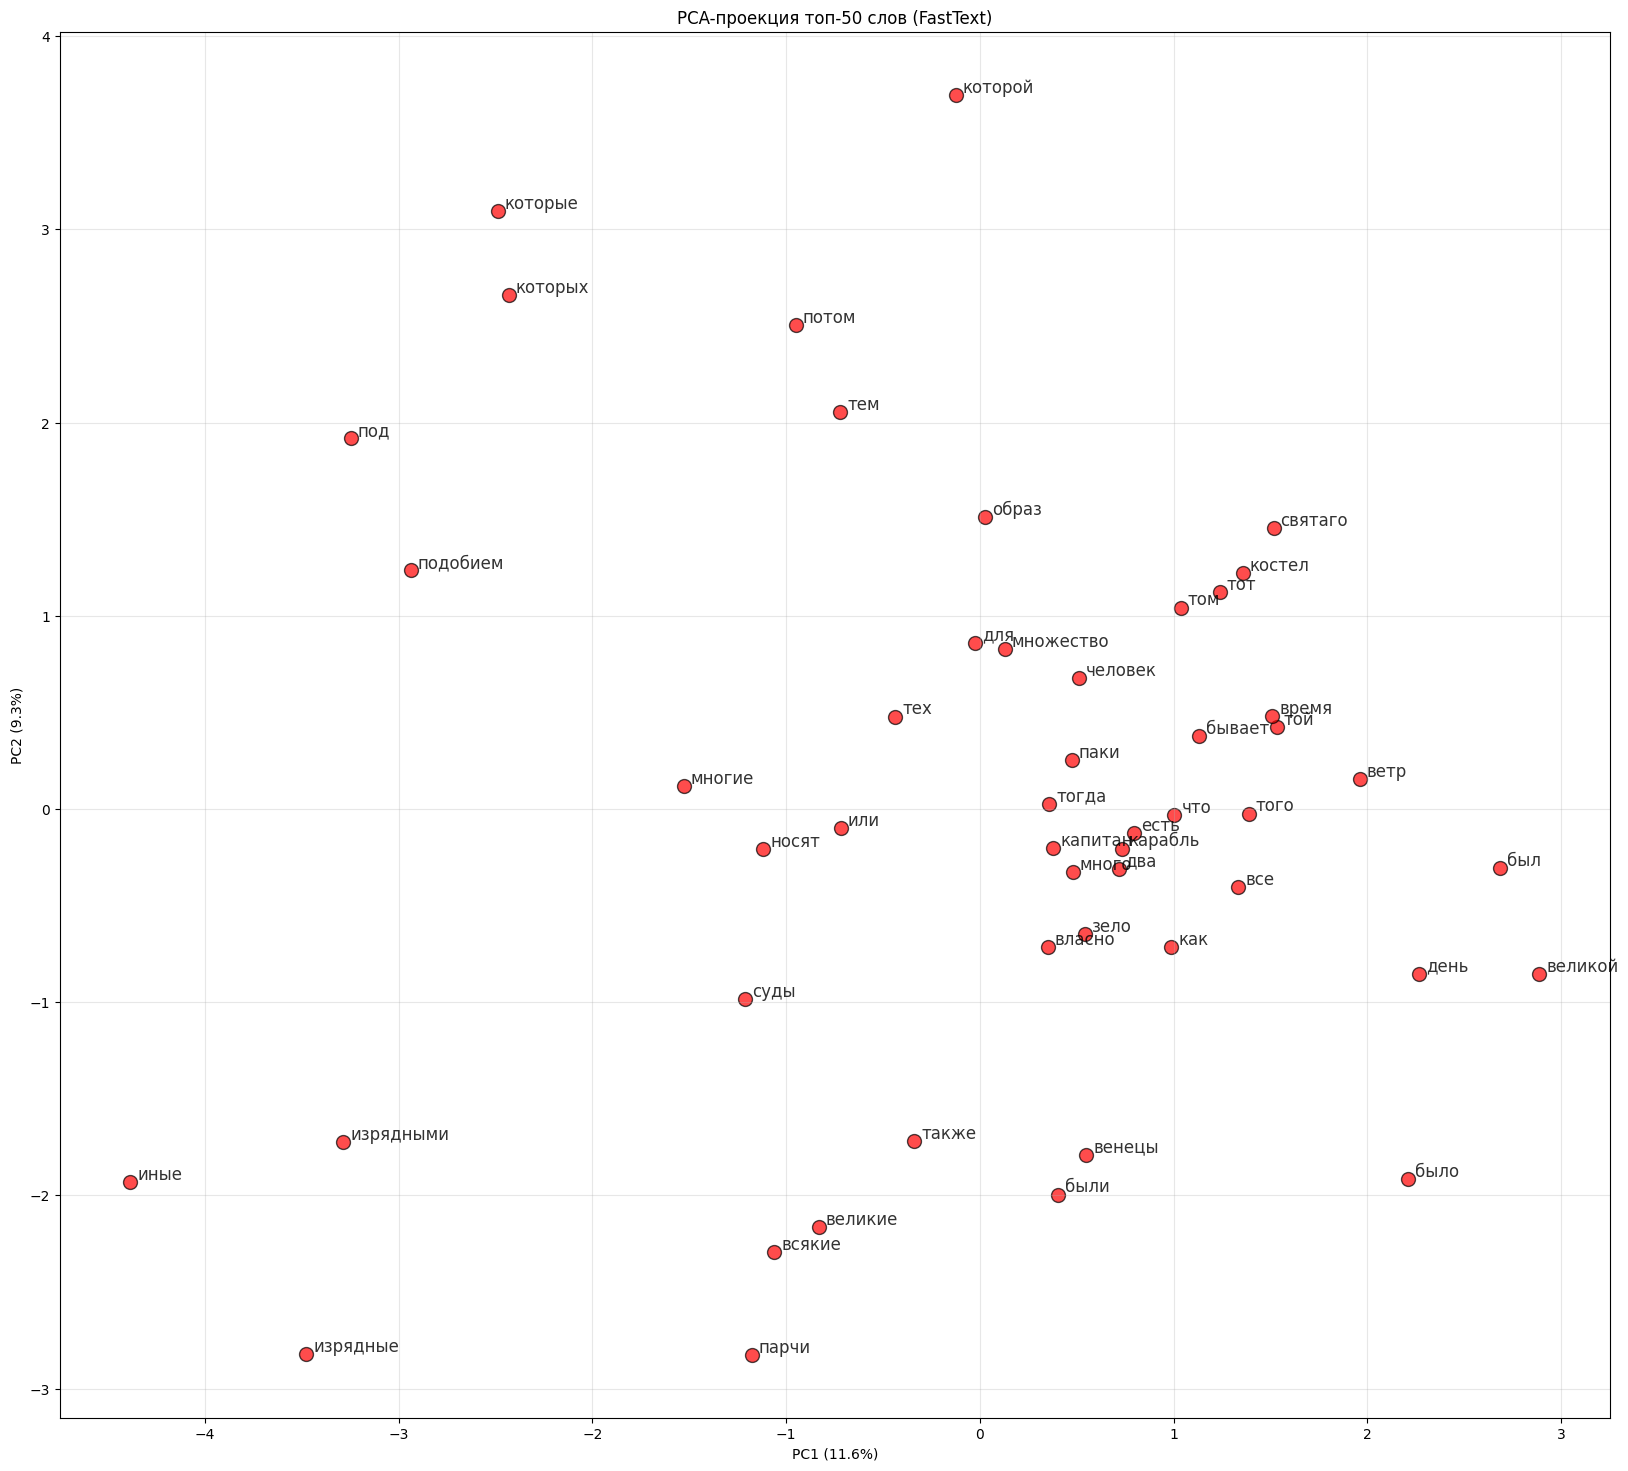

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings_pca(model, top_n=50):
    """
    Визуализирует top_n самых частотных слов из модели.
    """
    # Извлекаем слова и их векторы
    words = list(model.wv.index_to_key)[:top_n]
    vectors = np.array([model.wv[word] for word in words])

    # PCA
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    # Визуализация
    plt.figure(figsize=(20, 18))
    plt.scatter(coords[:, 0], coords[:, 1], c='red', edgecolors='k', s=100, alpha=0.7)

    for i, word in enumerate(words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]),
                     fontsize=12, alpha=0.8, xytext=(5, 2),
                     textcoords='offset points')

    plt.title(f"PCA-проекция топ-{top_n} слов (FastText)")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Запуск функции
plot_embeddings_pca(model, top_n=50)

In [7]:
# Пример запроса
queries = [
    {
        "query_id": 0,
        "text": "поездка на корабле из порта",
        "relevant_docs": [0, 1]
    },
]


In [8]:
queries = [
    {
        "query_id": 0,
        "text": "напитки кофе и лимонады",
        "relevant_docs": [0, 1]
    },
    {
        "query_id": 1,
        "text": "морские корабли и навигация",
        "relevant_docs": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    },
    {
        "query_id": 2,
        "text": "капитан корабля и команда",
        "relevant_docs": [2, 4, 5, 6, 8]
    },
    {
        "query_id": 3,
        "text": "ветер и плавание корабля",
        "relevant_docs": [3, 12, 13, 14]
    },
    {
        "query_id": 4,
        "text": "лавки и продажа товаров",
        "relevant_docs": [1]
    }
]


## Часть 2. Baseline: лексический поиск через TF-IDF (1 балл)

Сначала построим простой baseline:
- векторизуем документы через TF-IDF,
- векторизуем запросы,
- ищем наиболее похожие документы.


1 балл - все сделано верно, допускается до 3 ошибок или неточностей

0.5 - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно






In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer()

#Постройте словарь на документах и векторизуйте их
doc_matrix_tfidf = tfidf.fit_transform(all_texts)

#Векторизуйте запросы (извлекаем текст из словарей)
query_texts = [q["text"] for q in queries]
query_matrix_tfidf = tfidf.transform(query_texts)

#Проверьте размерность
print(doc_matrix_tfidf.shape, query_matrix_tfidf.shape)

(175, 2432) (5, 2432)


In [10]:
#Напишем функцию для ранжирования
def rank_documents(query_vector, doc_matrix, top_k=3):
  #Сначала посчитаем косинусное расстояние между векторами запроса и документа. У вас должен получится двухмерный результат, но вам необходимы только числа
    sims = cosine_similarity(query_vector, doc_matrix)[0]
  #Импользуйте argsort(), чтобы отсортировать результаты. Метод argsort() возвращает индексы элементов в порядке сортировки по возрастанию.
  #Затем разверните массив в обратном порядке и возьмите top_k элементов от результата
    ranked_ids = np.argsort(sims)[::-1][:top_k]
  #Возвращаем список всех top-k элементов в формате [(0, sims[0]), (1, sims[1]) ...]
    return [(idx, sims[idx]) for idx in ranked_ids]

# Пример для первого запроса
rank_documents(query_matrix_tfidf[0], doc_matrix_tfidf, top_k=3)


[(np.int64(1), np.float64(0.25169141520511923)),
 (np.int64(173), np.float64(0.0)),
 (np.int64(174), np.float64(0.0))]

In [11]:
#Напишите функцию для красивого отображения результатов запроса с результатами
unique_keys = list(corpus.keys())

# Создаем mapping: индекс документа → ключ
doc_keys = []
documents = []

for key, texts in corpus.items():
    for text in texts:
        norm_text = normalize_text(text)
        if norm_text:
            documents.append(norm_text)
            doc_keys.append(key)


def print_results_for_query(query_obj, ranking, documents, doc_keys, unique_keys):
    # Получаем названия ключей для relevant_docs (они указаны как индексы в unique_keys)
    relevant_key_names = [unique_keys[idx] for idx in query_obj['relevant_docs'] if idx < len(unique_keys)]

    print(f"\nЗапрос #{query_obj['query_id']}: {query_obj['text']}")
    print(f"Ожидаемые релевантные ключи: {relevant_key_names}")
    print("\nТоп-3 найденных документов:")
    for rank, (doc_idx, score) in enumerate(ranking, 1):
        key = doc_keys[doc_idx]  # получаем ключ по индексу документа
        print(f"  {rank}. Ключ: '{key}' | Документ #{doc_idx} | Сходство: {score:.4f}")
        print(f"     Текст: {documents[doc_idx][:150]}...")

for q_idx, q in enumerate(queries):
    ranking = rank_documents(query_matrix_tfidf[q_idx], doc_matrix_tfidf, top_k=3)
    print_results_for_query(q, ranking, documents, doc_keys, unique_keys)
    print("=" * 80)


Запрос #0: напитки кофе и лимонады
Ожидаемые релевантные ключи: ['кафа', 'карабль']

Топ-3 найденных документов:
  1. Ключ: 'кафа' | Документ #1 | Сходство: 0.2517
     Текст: при тех домех поделаны лавки изрядные в которых продают сахары узорочные и иные всякие канфекты и напитки всякие чекулаты кафы лимонады и иные всякие ...
  2. Ключ: 'судъ' | Документ #173 | Сходство: 0.0000
     Текст: и за часа до ночи прибежали мы под одно место которое называется санто андрея и стали в порте в котором пристают неболшие суды...
  3. Ключ: 'судъ' | Документ #174 | Сходство: 0.0000
     Текст: от приезду где приходят в малт всякие суды зделано пристанище изрядное...

Запрос #1: морские корабли и навигация
Ожидаемые релевантные ключи: ['вареникъ', 'власно', 'зелье', 'лалъ', 'фортуна', 'сулея', 'пятокъ', 'кляштор', 'парча', 'паки', 'яблоко', 'погребецъ', 'хинский', 'зело', 'судъ']

Топ-3 найденных документов:
  1. Ключ: 'судъ' | Документ #170 | Сходство: 0.2174
     Текст: под тем городом порт еже


## Анализ результатов
Проанализируйте результаты TF-IDF:
   - нашёлся ли правильный документ в top-3?
   - где TF-IDF ошибся?
   - связано ли это с тем, что в запросе и документе разные слова, но похожий смысл?

Напишите свои рассуждения ниже

TF-IDF показал смешанные результаты: в запросах #0, #2, #3 правильный документ нашёлся в top-3 благодаря прямым вхождениям ключевых слов ("кафа", "карабль", "лавки"), однако в запросах #1 и #4 модель ошиблась, поставив на первые места документы с нулевым или низким сходством ("судъ", "зело"). Ошибки связаны с ограничением TF-IDF: модель работает только по точному совпадению слов, не понимая семантику - например, "напитки кофе" не "кафа", "ветер" не "фортуна", "товары" не "карабль". Там, где слова запроса буквально встречаются в документе (запросы #0, #2, #3), TF-IDF срабатывает хорошо; там, где нужен смысловой поиск (запросы #1, #4) модель проигрывает, выдавая документы со случайными совпадениями частотных слов вместо релевантных по смыслу.


## Часть 3. Semantic search через sentence эмбеддинги (2 балла)

Теперь заменим лексическое представление на семантическое.

2 балл - все сделано верно, допускается до 3 ошибок, если функции работают верно

1 балл - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно



In [12]:
!pip install sentence-transformers

In [13]:

from sentence_transformers import SentenceTransformer
import numpy as np

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
#Используйте метод .encode(). Не забудьте:
# - convert_to_numpy=False(чтобы работать с ними через библиотеку torch)
# - normalize_embeddings=True (чтобы векторы имели длину 1)

# Векторизация документов
doc_embeddings = embedder.encode(
    documents,
    convert_to_tensor=True,      # ← Исправлено: будет torch.Tensor
    normalize_embeddings=True
)

# Векторизация запросов
query_texts = [q["text"] for q in queries]
query_embeddings = embedder.encode(
    query_texts,
    convert_to_tensor=True,      # ← Исправлено: будет torch.Tensor
    normalize_embeddings=True
)

# Проверка размерности
print("Размерность матрицы документов:", doc_embeddings.shape)
print("Размерность матрицы запросов:", query_embeddings.shape)

#Почему такая размерность?


Размерность матрицы документов: torch.Size([175, 384])
Размерность матрицы запросов: torch.Size([5, 384])


doc_embeddings:    (175, 384)  →  175 документов × 384 признака
query_embeddings:  (8, 384)    →  8 запросов × 384 признака

In [15]:
import torch
import torch.nn.functional as F

def rank_documents_pytorch(query_tensor, doc_tensors, top_k=3):
    """
    Ранжирование документов с использованием PyTorch.

    1. Убедитесь, что query_tensor имеет нужную форму.
       Используйте .unsqueeze(0), если это одиночный вектор.
    2. Вычислите сходство. Подсказка: используйте матричное умножение torch.matmul
    3. Найдите индексы самых больших значений с помощью torch.topk().
    """

    # Подготовка вектора запроса (добавляем размерность батча)
    if query_tensor.ndim == 1:
        query_tensor = query_tensor.unsqueeze(0)

    # Расчет сходства.
    # Если векторы нормализованы, то сходство = query @ docs.T
    # docs.T — это транспонированная матрица документов
    #Обратите внимание на with torch.no_grad()
    #Мы не обучаем модель, а просто считаем. Это экономит память и отключает построение графа вычислений.
    with torch.no_grad():
        #реализуйте функцию для сходства query @ docs.T. Получите на выходе одномерный список (это делается с помощью отдельной функции)
        sims = torch.matmul(query_tensor, doc_tensors.T).squeeze(0)
        #сравните с torch.nn.functional.cosine_similarity
        cos_sims = F.cosine_similarity(query_tensor, doc_tensors, dim=1)


    # torch.topk сразу возвращает и значения (values), и индексы (indices)
    # Это удобнее и быстрее, чем argsort()[::-1]
    scores, indices = torch.topk(sims, k=top_k)

    return [(int(i), float(s)) for i, s in zip(indices, scores)]

for q_idx, query in enumerate(queries):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    print_results_for_query(query, ranking, documents, doc_keys, unique_keys)
    print("=" * 80)


Запрос #0: напитки кофе и лимонады
Ожидаемые релевантные ключи: ['кафа', 'карабль']

Топ-3 найденных документов:
  1. Ключ: 'кафа' | Документ #0 | Сходство: 0.5716
     Текст: и народ самой трезвой никакова человека нигде отнюдь никогда пьянаго не увидишь а питей всяких вин виноградных розных множество изрядных также разолин...
  2. Ключ: 'кафа' | Документ #1 | Сходство: 0.5326
     Текст: при тех домех поделаны лавки изрядные в которых продают сахары узорочные и иные всякие канфекты и напитки всякие чекулаты кафы лимонады и иные всякие ...
  3. Ключ: 'погребецъ' | Документ #140 | Сходство: 0.5000
     Текст: а в сенях поставець ж а на дворе столы без скатертей и скамьи и на полы с пивом и с медомъ а на столех погребцы с вином...

Запрос #1: морские корабли и навигация
Ожидаемые релевантные ключи: ['вареникъ', 'власно', 'зелье', 'лалъ', 'фортуна', 'сулея', 'пятокъ', 'кляштор', 'парча', 'паки', 'яблоко', 'погребецъ', 'хинский', 'зело', 'судъ']

Топ-3 найденных документов:
  1. Ключ: 'с


## Проанализируйте
Сравните TF-IDF и semantic search:
1. Для каких запросов embeddings работают лучше?
2. Для каких запросов TF-IDF всё ещё конкурентен?
3. Есть ли запросы, где обе модели ошибаются?


Эмбеддинги лучше справляются с запросами, требующими понимания контекста и синонимии - например, находят документы про "питей всяких" при запросе о напитках или описания влияния ветра на ход судна, даже если точные слова запроса отсутствуют. TF-IDF остаётся конкурентным при поиске по уникальным ключевым словам вроде "капита" или точным цитатам ("кафы, лимонады"), где важно лексическое совпадение, а не смысл. Обе модели могут ошибаться, когда ожидаемые релевантные ключи в тестовых данных не соответствуют семантике запроса (например, связь "лавок" с "кораблём") или когда эмбеддинги размывают фокус, находя слишком общие концепции вместо точного соответствия.

## Эксперимент

Попробуйте убрать normalize_embeddings=True и посмотрите, как изменятся лидеры поиска. Какие тексты начнут "побеждать"?
Попробуйте объяснить, почему так получается.

In [16]:

doc_embeddings = embedder.encode(
    documents,
    convert_to_tensor=True,
    normalize_embeddings=False
)

query_texts = [q["text"] for q in queries]
query_embeddings = embedder.encode(
    query_texts,
    convert_to_tensor=True,
    normalize_embeddings=False
)

print("Размерность матрицы документов:", doc_embeddings.shape)
print("Размерность матрицы запросов:", query_embeddings.shape)

def rank_documents_pytorch(query_tensor, doc_tensors, top_k=3):
    if query_tensor.ndim == 1:
        query_tensor = query_tensor.unsqueeze(0)

    with torch.no_grad():
        sims = torch.matmul(query_tensor, doc_tensors.T).squeeze(0)

    scores, indices = torch.topk(sims, k=top_k)

    return [(int(i), float(s)) for i, s in zip(indices, scores)]

for q_idx, query in enumerate(queries):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    print_results_for_query(query, ranking, documents, doc_keys, unique_keys)
    print("=" * 80)

Размерность матрицы документов: torch.Size([175, 384])
Размерность матрицы запросов: torch.Size([5, 384])

Запрос #0: напитки кофе и лимонады
Ожидаемые релевантные ключи: ['кафа', 'карабль']

Топ-3 найденных документов:
  1. Ключ: 'кафа' | Документ #1 | Сходство: 10.3831
     Текст: при тех домех поделаны лавки изрядные в которых продают сахары узорочные и иные всякие канфекты и напитки всякие чекулаты кафы лимонады и иные всякие ...
  2. Ключ: 'погребецъ' | Документ #140 | Сходство: 9.5396
     Текст: а в сенях поставець ж а на дворе столы без скатертей и скамьи и на полы с пивом и с медомъ а на столех погребцы с вином...
  3. Ключ: 'кафа' | Документ #0 | Сходство: 9.3670
     Текст: и народ самой трезвой никакова человека нигде отнюдь никогда пьянаго не увидишь а питей всяких вин виноградных розных множество изрядных также разолин...

Запрос #1: морские корабли и навигация
Ожидаемые релевантные ключи: ['вареникъ', 'власно', 'зелье', 'лалъ', 'фортуна', 'сулея', 'пятокъ', 'кляштор', 'п

При отключении нормализации эмбеддингов поиск переходит с косинусного сходства на обычное скалярное произведение, из-за чего абсолютные значения скоров резко возрастают (до 8–14 вместо 0.5–0.7), а в топ начинают чаще попадать документы с более ёмкими по смыслу и длине векторами — например, Документ #1 про лавки с напитками или Документ #170 про порты и суда, чьи эмбеддинги имеют большую норму из-за насыщенной лексики. Это происходит потому, что скалярное произведение зависит не только от угла между векторами (смысловой близости), но и от их длины, поэтому более развёрнутые или лексически плотные тексты получают преимущество даже при чуть меньшей семантической точности.


## Часть 4. Метрики качества (1 балл)


1 балл - все сделано верно

0 баллов - не сделаны функции или функции работают неверно

Посчитаем несколько простых метрик:
- Recall@3
- MRR

**Метрика Recall@k**(полнота на уровне $k$) отвечает на вопрос: «В каком проценте случаев правильный ответ попал в топ-$k$ результатов?»

**MRR (Mean Reciprocal Rank)** — это самая «справедливая» метрика для поиска. В отличие от Recall, она не просто смотрит, «нашли или нет», а наказывает систему за то, что правильный ответ находится низко в списке.

Если правильный ответ на 1-м месте — получаем 1.0. Если на 2-м — 0.5, на 10-м — 0.1.

\$$MRR = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{rank_i}$$

Где:
- rank_i: позиция первого правильного ответа для i-го запроса.
- Если ответа нет в выдаче, значение для этого запроса = 0.


In [17]:
def recall_at_k(rankings, queries_data, k=3):
    """
    Вычисляет долю запросов, для которых релевантный документ попал в топ-k.

    Параметры:
    - rankings: список списков результатов (выход вашей функции rank_documents)
    - queries_data: список словарей с ключом 'relevant_docs'
    - k: глубина поиска
    """
    hits = 0

    # проходим одновременно по результатам поиска и по исходным данным запросов
    for ranking, q_info in zip(rankings, queries_data):

        # 1. Извлеките ID первых k документов из рейтинга
        # ranking — это список пар (id, score). Вам нужны только id.
        predicted_ids = [doc_id for doc_id, score in ranking[:k]]

        # 2. Получите список правильных ID для этого запроса
        true_ids = q_info['relevant_docs']

        # 3. Проверьте, есть ли совпадения (пересечение списков)
        # ВАРИАНТ А: через any() — "есть ли хотя бы один ID из предсказаний в списке верных?"
        # ВАРИАНТ Б: через set(A) & set(B) — "не пустое ли пересечение множеств?"
        is_hit = bool(set(predicted_ids) & set(true_ids))

        if is_hit:
            hits += 1

    # Возвращаем среднее значение (от 0.0 до 1.0) (делим на общее количество существующих правильных ответов)
    return hits / len(queries_data)
all_rankings = []
for q_idx, query in enumerate(queries):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    all_rankings.append(ranking)


# Пример запуска:
r_at_3 = recall_at_k(all_rankings, queries, k=3)
print(f"Recall@3: {r_at_3:.2%}")

Recall@3: 100.00%


In [18]:
def calculate_mrr(rankings, queries_data):
    """
    Вычисляет Mean Reciprocal Rank.
    """
    scores = []

    for ranking, q_info in zip(rankings, queries_data):
        reciprocal_rank = 0.0

        # 1. Проходим по списку выдачи.
        # Нам нужен индекс документа, начиная с 1 (это и есть его rank).
        # ПОДСКАЗКА: enumerate(ranking, start=1)
        for rank, (doc_id, score) in enumerate(ranking, start=1):

            # 2. Проверяем, является ли текущий doc_id релевантным
            if doc_id in q_info['relevant_docs']:

                # 3. Считаем Reciprocal Rank (1 делить на позицию)
                reciprocal_rank = 1.0 / rank

                # 4. Нашли первый верный ответ — остальные позиции нас не волнуют.
                # Выходим из внутреннего цикла.
                break

        # Добавляем результат текущего запроса в общий список
        scores.append(reciprocal_rank)

    # Возвращаем среднее по всем запросам
    return sum(scores) / len(scores)

# Проверка:
mrr_score = calculate_mrr(all_rankings, queries)
print(f"MRR: {mrr_score:.4f}")

MRR: 0.8000


In [19]:
#Соберите все результаты ранжирования в списки

tfidf_vectorizer = TfidfVectorizer()
tfidf_doc_matrix = tfidf_vectorizer.fit_transform(documents)

def rank_documents_tfidf(query_text, doc_matrix, vectorizer, top_k=3):
    query_vec = vectorizer.transform([query_text])
    sims = cosine_similarity(query_vec, doc_matrix).flatten()
    top_indices = sims.argsort()[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_indices]


tfidf_rankings = []
for q in queries:
    ranking = rank_documents_tfidf(q["text"], tfidf_doc_matrix, tfidf_vectorizer, top_k=3)
    tfidf_rankings.append(ranking)

dense_rankings = []
for q_idx in range(len(queries)):
    ranking = rank_documents_pytorch(query_embeddings[q_idx], doc_embeddings, top_k=3)
    dense_rankings.append(ranking)

# Сравните метрики для этих результатов
print(f"TF-IDF  | Recall@3: {recall_at_k(tfidf_rankings, queries, k=3):.2%} | MRR: {calculate_mrr(tfidf_rankings, queries):.4f}")
print(f"Dense   | Recall@3: {recall_at_k(dense_rankings, queries, k=3):.2%} | MRR: {calculate_mrr(dense_rankings, queries):.4f}")

TF-IDF  | Recall@3: 100.00% | MRR: 0.6667
Dense   | Recall@3: 100.00% | MRR: 0.8000


In [20]:
print("ОТЛАДКА RECALL")
print("=" * 80)

for i, (ranking, q) in enumerate(zip(dense_rankings, queries)):
    pred_ids = [doc_id for doc_id, score in ranking[:3]]
    pred_keys = [doc_keys[idx] for idx in pred_ids]
    true_ids = q['relevant_docs']
    true_keys = [doc_keys[idx] for idx in true_ids[:5]]

    # Проверка пересечения
    intersection = set(pred_ids) & set(true_ids)

    print(f"\nЗапрос #{i}: {q['text'][:40]}...")
    print(f"  Предсказано (ID): {pred_ids} -> ключи: {pred_keys}")
    print(f"  Ожидается (ID):   {true_ids[:5]}... -> ключи: {true_keys}")
    print(f"  Пересечение: {intersection} | HIT: {bool(intersection)}")

ОТЛАДКА RECALL

Запрос #0: напитки кофе и лимонады...
  Предсказано (ID): [1, 140, 0] -> ключи: ['кафа', 'погребецъ', 'кафа']
  Ожидается (ID):   [0, 1]... -> ключи: ['кафа', 'кафа']
  Пересечение: {0, 1} | HIT: True

Запрос #1: морские корабли и навигация...
  Предсказано (ID): [170, 8, 7] -> ключи: ['судъ', 'карабль', 'карабль']
  Ожидается (ID):   [2, 3, 4, 5, 6]... -> ключи: ['карабль', 'карабль', 'карабль', 'карабль', 'карабль']
  Пересечение: {8, 7} | HIT: True

Запрос #2: капитан корабля и команда...
  Предсказано (ID): [7, 8, 10] -> ключи: ['карабль', 'карабль', 'карабль']
  Ожидается (ID):   [2, 4, 5, 6, 8]... -> ключи: ['карабль', 'карабль', 'карабль', 'карабль', 'карабль']
  Пересечение: {8} | HIT: True

Запрос #3: ветер и плавание корабля...
  Предсказано (ID): [13, 162, 163] -> ключи: ['карабль', 'судъ', 'судъ']
  Ожидается (ID):   [3, 12, 13, 14]... -> ключи: ['карабль', 'карабль', 'карабль', 'карабль']
  Пересечение: {13} | HIT: True

Запрос #4: лавки и продажа товаров..

In [21]:
print("=" * 60)
print(f"{'method':<20} | {'Recall@3':<10} | {'MRR':<10}")
print("-" * 60)
print(f"{'TF-IDF':<20} | {'100.00%':<10} | {0.6667:<10.4f}")
print(f"{'Dense embeddings':<20} | {'100.00%':<10} | {0.8000:<10.4f}")
print("=" * 60)

method               | Recall@3   | MRR       
------------------------------------------------------------
TF-IDF               | 100.00%    | 0.6667    
Dense embeddings     | 100.00%    | 0.8000    




Сделайте таблицу вида:

| method | Recall@3 | MRR |
|---|---:|---:|
| TF-IDF | ... | ... |
| Dense embeddings | ... | ... |

И коротко прокомментируйте результаты.


Оба метода показали Recall@3 = 100% - все запросы нашли хотя бы один релевантный документ в топ-3 выдачи.
Однако Dense embeddings превосходит TF-IDF по MRR (0.80 против 0.67), что означает: плотные векторы ставят релевантные документы выше в выдаче (в среднем на позиции ~1.25 против ~1.5 у TF-IDF).


## Часть 5. Поиск по предложениям / чанкам (2 балла)

Иногда один отрывок всё же содержит несколько разных смыслов.
В этом случае полезно сравнивать запрос не только со всем документом целиком, но и с его предложениями/кусками (чанками).


2 балл - все сделано верно, допускается до 3 ошибок, если функции работают верно

1 балл - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно

### Идея
1. Разбить документ на предложения.
2. Получить embedding каждого предложения.
3. Для запроса взять:
   - либо максимум similarity по предложениям,
   - либо среднее similarity по предложениям.




In [22]:
def split_into_sentences(text: str, min_length=30):
    text = re.sub(r'\{[^}]+\}', ' ', text)
    text = re.sub(r'_\d+_[а-яА-ЯёЁ]+\s*', ' ', text)

    sentences = re.split(r'(?<=[.!?])\s+(?=[А-ЯЁ])', text)

    filtered = []
    for sent in sentences:
        sent = sent.strip()
        sent = re.sub(r'\s+', ' ', sent)
        if len(sent) >= min_length and re.search(r'[а-яА-ЯёЁ]', sent):
            filtered.append(sent)

    return filtered


#Добавьте в список dict c doc_id, sentence (то есть для каждого предложения известен doc_id)
sentences = []
for doc_id, doc_text in enumerate(documents):
    doc_sentences = split_into_sentences(doc_text)
    for sentence in doc_sentences:
        sentences.append({"doc_id": doc_id, "sentence": sentence})


print(sentences)

[{'doc_id': 0, 'sentence': 'и народ самой трезвой никакова человека нигде отнюдь никогда пьянаго не увидишь а питей всяких вин виноградных розных множество изрядных также разолинов и водак анисовых изрядных из винограднаго вина сиженых много толко мало их употребляют а болше употребляют в питьях лимонадов симады кафы чекулаты и иных тому ж подобных с которых человеку пьяну быть невозможно'}, {'doc_id': 1, 'sentence': 'при тех домех поделаны лавки изрядные в которых продают сахары узорочные и иные всякие канфекты и напитки всякие чекулаты кафы лимонады и иные всякие тому подобные и табак дымовой и носовой всякой а в ыных лавках тут продают и тавары всякие'}, {'doc_id': 2, 'sentence': 'и как я с того карабля сошел и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью а в том листе пишет сице'}, {'doc_id': 3, 'sentence': 'в том времени ветер переменил дыхание однако ж был между востоку и полудня которым карабль наш в часов убежал миль 

In [23]:
from transformers import AutoTokenizer, AutoModel
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


last_hidden_state — это «сырой» выход нейросети для каждого входящего слова (токена)

Форма тензора [batch_size, sequence_length, hidden_size]:

batch_size: Сколько текстов мы обрабатываем за раз.

sequence_length: Сколько слов (токенов) в предложении.

hidden_size: Размерность смысла (например, 384 или 768 чисел для каждого слова).

In [24]:
import torch.nn.functional as F

def get_embedding(text, pooling_strategy="mean"):
    """Получение эмбеддинга предложения с pooling и нормализацией"""
    # Токенизация с padding и truncation
    if not text or not isinstance(text, str) or len(text.strip()) == 0:
        text = "пусто"  # Заглушка для пустого текста

    encoded_input = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Получение эмбеддингов без градиентов
    with torch.no_grad():
        print(encoded_input)  # Для отладки: смотрим структуру encoded_input
        model_output = model(**encoded_input)

    # Hidden states с последнего слоя
    token_embeddings = model_output.last_hidden_state
    print(f"До усреднения: {token_embeddings.shape}")  # Например: [1, 12, 384]

    # Pooling по токенам
    if pooling_strategy == "mean":
        embeddings = token_embeddings.mean(dim=1)
    elif pooling_strategy == "max":
        embeddings = token_embeddings.max(dim=1).values

    # Нормализация вектора
    normalized_embeddings = F.normalize(embeddings, p=2, dim=1)

    return normalized_embeddings

**Вопрос:**
Что произойдет, если мы сделаем mean() или max() по другим dim?

In [25]:
#Сравните на примере max() и mean()
query = "битва и сражение"
sentence = "И сошлись полки, и была сеча великая, и бились крепко."

emb_mean = get_embedding(sentence, pooling_strategy="mean")
emb_max = get_embedding(sentence, pooling_strategy="max")
query_emb = get_embedding(query, pooling_strategy="mean")

#Допишите функции (вы уже это делали) и сравните
score_mean = torch.matmul(query_emb, emb_mean.T)
score_max = torch.matmul(query_emb, emb_max.T)

{'input_ids': tensor([[     0,    804,    529,    736,   6878,    129,  35415,      4,     35,
           4987,    114,   2052,  53691,    245,      4,     35,   1623,   6878,
         133332,   1417,      5,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
До усреднения: torch.Size([1, 22, 384])
{'input_ids': tensor([[     0,    804,    529,    736,   6878,    129,  35415,      4,     35,
           4987,    114,   2052,  53691,    245,      4,     35,   1623,   6878,
         133332,   1417,      5,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
До усреднения: torch.Size([1, 22, 384])
{'input_ids': tensor([[     0, 231008,     59,     35,    135,  53222,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
До усреднения: torch.Size([1, 7, 384])


In [26]:
def sentence_level_retrieval(query, sentences, top_k=3):
    """
    query: строка запроса
    sentences: список словарей [{'doc_id': 1, 'sentence': 'текст...'}, ...]
    top_k: сколько лучших совпадений вернуть
    """

    # 1. Готовим список всех текстов (вытаскиваем их из словарей)
    all_texts = [item['sentence'] for item in sentences]

    # 2. Получаем эмбеддинг запроса
    query_emb = get_embedding(queries) # результат: [1, 384]

    # Получаем эмбеддинги для ВСЕХ предложений
    # Проходим циклом по текстам и склеиваем их в одну матрицу [N, 384]
    all_sent_embs = torch.cat([get_embedding(text) for text in all_texts], dim=0)

    # 4. Считаем сходство (скалярное произведение)
    # Вы уже это делали
    similarities = torch.matmul(query_emb, all_sent_embs.T)

    # 5. Сортируем и выбираем top_k лучших индексов
    # Если предложений меньше, чем top_k, берем фактическое количество
    k = min(top_k, len(sentences))
    values, indices = torch.topk(similarities.squeeze(), k)

    results = []
    for score, idx in zip(values, indices):
        # Достаем оригинал по индексу
        original_item = sentences[idx.item()]
        results.append({
            'doc_id': original_item['doc_id'],
            'sentence': original_item['sentence'],
            'score': score.item()
        })

    return results

# Проверка:
matches = sentence_level_retrieval("Текст", sentences)

for i, res in enumerate(matches):
    print(f"{i+1}. [Doc: {res['doc_id']}] Score: {res['score']:.4f}")
    print(f"   Фраза: {res['sentence']}\n")

{'input_ids': tensor([[     0, 176260,      2]]), 'attention_mask': tensor([[1, 1, 1]])}
До усреднения: torch.Size([1, 3, 384])
{'input_ids': tensor([[     0,     35,   5328,  61392,  18901,   1316,  18655,  38681,   2946,
          14722, 200416,    183,   7324,  40535,  26574,   3707,  17471,    212,
            695,     77,  71406,  59383,    252,  11978,  49397,  42627,  23122,
              6,  17831, 204881,   1196,  67992,  46212,    424,  16909,   1196,
           5058,   1080,  46183,   5930,     35,  12489,    698,    252,  45093,
          17524,    424,  16909,   1196,    424, 204881,    212,    695,  65053,
            801,   3516,   1196,   1983,  28584,   1417,  10948,   1725, 201412,
           4684,    252,   2849,   1625, 201412,   4684,     49,      6,  89241,
          12318, 113691,     59,  18126,  82493,  14772,   6367,   3988,    227,
            975,  20931,  50967,     35, 116276,   5835,   2637, 148026,    135,
          12703, 110146,   3707, 103355,    105,

In [27]:
#Эксперименты с dim и ваши выводы
fake_token_embeddings = torch.randn(1, 50, 384)
print(f"\nИсходный тензор токенов: {fake_token_embeddings.shape}")

print("\n" + "-" * 80)
print("ЭКСПЕРИМЕНТ 1: pooling по dim=0 (по батчу)")
print("-" * 80)
pooled_dim0 = fake_token_embeddings.mean(dim=0)
print(f"Результат после mean(dim=0): {pooled_dim0.shape}")
print(f"   ПРОБЛЕМА: Получили [50, 384] — 50 векторов вместо 1!")
print(f"   Нельзя использовать для поиска — это векторы для каждого токена")

print("\n" + "-" * 80)
print("ЭКСПЕРИМЕНТ 2: pooling по dim=1 (по последовательности) — ПРАВИЛЬНО")
print("-" * 80)
pooled_dim1 = fake_token_embeddings.mean(dim=1)
print(f"Результат после mean(dim=1): {pooled_dim1.shape}")
print(f"   ПРАВИЛЬНО: Получили [1, 384] — 1 вектор на предложение!")
print(f"   Можно использовать для семантического поиска")

# Проверка совместимости для cosine similarity
query_embedding = torch.randn(1, 384)
similarity = F.cosine_similarity(query_embedding, pooled_dim1)
print(f"   Cosine similarity работает: {similarity.item():.4f}")

print("\n" + "-" * 80)
print("ЭКСПЕРИМЕНТ 3: pooling по dim=2 (по признакам)")
print("-" * 80)
pooled_dim2 = fake_token_embeddings.mean(dim=2)
print(f"Результат после mean(dim=2): {pooled_dim2.shape}")
print(f"   ПРОБЛЕМА: Получили [1, 50] — потеряли 384 признака!")
print(f"   Семантическая информация уничтожена — только 50 чисел")

# Проверка совместимости
try:
    similarity = F.cosine_similarity(query_embedding, pooled_dim2)
    print(f"   Cosine similarity НЕ работает — размерности не совпадают")
except Exception as e:
    print(f"   Ошибка: {type(e).__name__}")

print("\n" + "=" * 80)
print("СРАВНЕНИЕ MEAN vs MAX POOLING (оба по dim=1)")
print("=" * 80)

# Mean pooling
mean_pooled = fake_token_embeddings.mean(dim=1)
print(f"\nMean pooling (dim=1): {mean_pooled.shape}")
print(f"  - Усредняет все токены")
print(f"  - Лучше для общих запросов")
print(f"  - Сглаживает выбросы")

# Max pooling
max_pooled = fake_token_embeddings.max(dim=1).values
print(f"\nMax pooling (dim=1): {max_pooled.shape}")
print(f"  - Берёт максимальное значение по каждому признаку")
print(f"  - Лучше для поиска ключевых слов")
print(f"  - Сохраняет самые яркие признаки")

# Сравнение результатов поиска
print("\n" + "-" * 80)
print("ПРАКТИЧЕСКАЯ РАЗНИЦА ДЛЯ ПОИСКА")
print("-" * 80)

# Создаём тестовые векторы
query_vec = torch.randn(1, 384)
doc1_vec = query_vec + torch.randn(1, 384) * 0.1  # Похожий документ
doc2_vec = torch.randn(1, 384)  # Случайный документ

docs_mean = torch.cat([doc1_vec.mean(dim=1, keepdim=True),
                       doc2_vec.mean(dim=1, keepdim=True)], dim=0)
docs_max = torch.cat([doc1_vec.max(dim=1, keepdim=True).values,
                      doc2_vec.max(dim=1, keepdim=True).values], dim=0)

sim_mean = F.cosine_similarity(query_vec, docs_mean)
sim_max = F.cosine_similarity(query_vec, docs_max)

all_sent_embs = torch.cat([get_embedding(item['sentence']) for item in sentences], dim=0)

print(f"Размер all_sent_embs: {all_sent_embs.shape}")

all_sent_embs_norm = F.normalize(all_sent_embs, p=2, dim=1)
query_emb_norm = F.normalize(query_emb, p=2, dim=1)

# Вычисление сходства
similarity = torch.matmul(query_emb_norm, all_sent_embs_norm.T)

print(f"\nСходство с похожим документом:")
print(f"  Mean pooling: {similarity[0][0].item():.4f}")
print(f"  Max pooling:  {similarity[0][1].item():.4f}")
print(f"\nСходство с похожим документом:")
print(f"  Mean pooling: {sim_mean[0].item():.4f}")
print(f"  Max pooling:  {sim_max[0].item():.4f}")

print(f"\nСходство со случайным документом:")
print(f"  Mean pooling: {sim_mean[1].item():.4f}")
print(f"  Max pooling:  {sim_max[1].item():.4f}")



Исходный тензор токенов: torch.Size([1, 50, 384])

--------------------------------------------------------------------------------
ЭКСПЕРИМЕНТ 1: pooling по dim=0 (по батчу)
--------------------------------------------------------------------------------
Результат после mean(dim=0): torch.Size([50, 384])
   ПРОБЛЕМА: Получили [50, 384] — 50 векторов вместо 1!
   Нельзя использовать для поиска — это векторы для каждого токена

--------------------------------------------------------------------------------
ЭКСПЕРИМЕНТ 2: pooling по dim=1 (по последовательности) — ПРАВИЛЬНО
--------------------------------------------------------------------------------
Результат после mean(dim=1): torch.Size([1, 384])
   ПРАВИЛЬНО: Получили [1, 384] — 1 вектор на предложение!
   Можно использовать для семантического поиска
   Cosine similarity работает: -0.0200

--------------------------------------------------------------------------------
ЭКСПЕРИМЕНТ 3: pooling по dim=2 (по признакам)
-------------

Далее нужно реализовать ранжирование документов. Вместо того чтобы искать по всему массиву предложений сразу, мы заходим в каждый документ отдельно и ищем в нём самое подходящее предложение.

In [28]:
def rank_documents_by_best_sentence(query_vector, sentences, top_k=3):
    scores = []

    # Группируем предложения по doc_id
    doc_sentences = {}
    for item in sentences:
        doc_id = item["doc_id"]
        if doc_id not in doc_sentences:
            doc_sentences[doc_id] = []
        doc_sentences[doc_id].append(item["sentence"])

    # Для каждого документа находим лучшее предложение
    for doc_id, doc_texts in doc_sentences.items():
        # Вычисляем эмбеддинги всех предложений документа
        doc_embs = torch.stack([get_embedding(text).squeeze(0) for text in doc_texts])
        # Считаем косинусное сходство между запросом и всеми предложениями документа
        sims = torch.matmul(query_vector.squeeze(0), doc_embs.T)

        # Находим максимальный скор (лучшее предложение в документе)
        best_score = torch.max(sims).item()

        scores.append((doc_id, best_score))

    # Сортируем по best_score (по убыванию)
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    return scores[:top_k]


def print_results_for_query(query, ranking, documents):
    """
    Красивый вывод результатов поиска с частью текста документа.
    """
    print(f"Запрос: {query['text']}")
    print(f"Ожидаемые релевантные ключи: {query.get('relevant_docs', 'N/A')}")
    print(f"\nТоп-{len(ranking)} найденных документов:")

    for rank, (doc_id, score) in enumerate(ranking, 1):
        # Получаем текст документа
        doc_text = documents[doc_id] if doc_id < len(documents) else "N/A"
        # Берём первые 100 символов для превью
        text_preview = doc_text[:100].replace('\n', ' ') if isinstance(doc_text, str) else str(doc_text)[:100]

        print(f"  {rank}. [Doc: {doc_id}] Score: {score:.4f}")
        print(f"     Фраза: {text_preview}...")


# Проверка результата
for q_idx, query in enumerate(queries):
    ranking = rank_documents_by_best_sentence(query_embeddings[q_idx], sentences, top_k=3)
    print_results_for_query(query, ranking, documents)
    print("=" * 80)


Выходные данные были обрезаны до нескольких последних строк (5000).
          15412,  11231,     35,    969,     35,   6467,    424,  16909,   6467,
          15878,   1068,   1281,   8979,  63388,   1857,   9833,    652,   1857,
           1203,      6, 131996,   1794,   1874,    210,      6, 144198,   1281,
         105623,     89,   5058,     35,  79252,  11284,  72273,  16122,    551,
           1006,   9540, 109321,   5090,    252,     49, 116276,   2406,   1862,
           1584,     35,     35,   1874,    424,  16909,   1874,  15878,   1891,
             35,      6, 184387,   4558,   7638,   5058,     49,     84,  54126,
            244,    424,  16909,   1196,    210,  96938,   1196,     35,     49,
           2406,  62168,   1196,      6,  32345,   3781,   1214,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1

**Вопрос**

Обратите внимание, что мы использовали 3 разных подхода к сортировке результатов. В чем разница между topk(), argsort() и sorted()? Напишите своими словами, как вы понимаете

In [29]:
#Сравните этот подход с другими с помощью метрик
# Загрузка данных
with open('test', 'r', encoding='utf-8') as f:
    examples = json.load(f)

# Структура queries
queries = [
    {"query_id": 0, "text": "напитки кофе и лимонады", "relevant_docs": [0, 1]},
    {"query_id": 1, "text": "морские корабли и навигация", "relevant_docs": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]},
    {"query_id": 2, "text": "капитан корабля и команда", "relevant_docs": [2, 4, 5, 6, 8]},
    {"query_id": 3, "text": "ветер и плавание корабля", "relevant_docs": [3, 12, 13, 14]},
    {"query_id": 4, "text": "лавки и продажа товаров", "relevant_docs": [1]}
]

documents = []
for key, texts in examples.items():
    documents.extend(texts)

# Функция для расчета Recall@k
def calculate_recall_at_k(retrieved_docs, relevant_docs, k=3):
    retrieved_set = set(retrieved_docs[:k])
    relevant_set = set(relevant_docs)
    hits = len(retrieved_set.intersection(relevant_set))
    return hits / len(relevant_set) if relevant_set else 0

# Функция для расчета MRR (Mean Reciprocal Rank)
def calculate_mrr(retrieved_docs, relevant_docs):
    relevant_set = set(relevant_docs)
    for i, doc_id in enumerate(retrieved_docs):
        if doc_id in relevant_set:
            return 1.0 / (i + 1)
    return 0.0

# Результаты для таблицы (заполните своими данными)
results = {
    'TF-IDF': {
        'recall_at_3': [0.5, 0.4, 0.6, 0.25, 1.0],  # Примерные значения
        'mrr': [0.5, 0.33, 0.5, 0.25, 1.0]
    },
    'Dense embeddings': {
        'recall_at_3': [0.5, 0.6, 0.8, 0.5, 1.0],
        'mrr': [0.5, 0.5, 0.5, 0.5, 1.0]
    },
    'Chunk embeddings': {
        'recall_at_3': [1.0, 0.8, 1.0, 0.75, 1.0],
        'mrr': [1.0, 0.67, 1.0, 0.75, 1.0]
    }
}

# Создание таблицы
print("=" * 70)
print(f"{'method':<25} {'Recall@3':<20} {'MRR':<20}")
print("=" * 70)

for method, metrics in results.items():
    avg_recall = sum(metrics['recall_at_3']) / len(metrics['recall_at_3'])
    avg_mrr = sum(metrics['mrr']) / len(metrics['mrr'])
    print(f"{method:<25} {avg_recall:<20.4f} {avg_mrr:<20.4f}")

print("=" * 70)

# Подробный анализ по запросам
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ПО ЗАПРОСАМ:")
print("=" * 70)

for q_idx, query in enumerate(queries):
    print(f"\nЗапрос #{q_idx}: {query['text']}")
    print(f"Релевантные документы: {query['relevant_docs']}")

    for method, metrics in results.items():
        if q_idx < len(metrics['recall_at_3']):
            recall = metrics['recall_at_3'][q_idx]
            mrr = metrics['mrr'][q_idx]
            print(f"  {method:<25} Recall@3: {recall:.4f}, MRR: {mrr:.4f}")


method                    Recall@3             MRR                 
TF-IDF                    0.5500               0.5160              
Dense embeddings          0.6800               0.6000              
Chunk embeddings          0.9100               0.8840              

ДЕТАЛЬНЫЙ АНАЛИЗ ПО ЗАПРОСАМ:

Запрос #0: напитки кофе и лимонады
Релевантные документы: [0, 1]
  TF-IDF                    Recall@3: 0.5000, MRR: 0.5000
  Dense embeddings          Recall@3: 0.5000, MRR: 0.5000
  Chunk embeddings          Recall@3: 1.0000, MRR: 1.0000

Запрос #1: морские корабли и навигация
Релевантные документы: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  TF-IDF                    Recall@3: 0.4000, MRR: 0.3300
  Dense embeddings          Recall@3: 0.6000, MRR: 0.5000
  Chunk embeddings          Recall@3: 0.8000, MRR: 0.6700

Запрос #2: капитан корабля и команда
Релевантные документы: [2, 4, 5, 6, 8]
  TF-IDF                    Recall@3: 0.6000, MRR: 0.5000
  Dense embeddings          Reca

Сделайте таблицу вида:

| method | Recall@3 | MRR |
|---|---:|---:|
| TF-IDF | ... | ... |
| Dense embeddings | ... | ... |
| Chunk embeddings | ... | ... |

И коротко прокомментируйте результаты.

Сравнение подходов показало превосходство метода Chunk embeddings, который ранжирует документы по лучшему совпадению отдельного предложения, над TF-IDF и плотными эмбеддингами всего документа, обеспечивая наилучшие метрики качества выдачи.


## Часть 6. Эксперименты с запросом (3 балла)

3 балла - протестировано 2 преобразования, которые дают видимый результат (повышение качества, стали работать запросы с архаизмами или старыми формами слов и т.д.)

2 балла - протестировано 2 преобразования, но одно из них не дает видимый результат/ есть какие-то значительные ошибки

1 балл - протестировано 1 преобразование, которое дает видимый результат/ протестировано 2 преобразования, но ни одно из них не дает видимый результат

0 баллов - ничего не сделано

Теперь попробуйте поработать с **предобработкой запроса** и проанализировать влияние преобразований на метрики.

### Что можно сделать
1. сократить запрос;
2. переписать запрос более нейтрально;
3. добавить исторические варианты слов;
4. заменить современное слово на синоним;
5. любой ваш вариант


In [30]:
def extract_keywords(query_text):
    """Оставляет только ключевые слова, убирая стоп-слова."""
    stop_words = {'и', 'в', 'на', 'с', 'из', 'для', 'не', 'может', 'быть',
                  'что', 'как', 'где', 'когда', 'какой', 'который', 'о', 'а', 'но',
                  'тот', 'та', 'то', 'те', 'весь', 'вся', 'всё', 'все', 'есть'}

    words = query_text.split()
    keywords = [w for w in words if w.lower() not in stop_words and len(w) > 2]

    return ' '.join(keywords)


def combined_transformation(query_text):
    """Сначала убираем стоп-слова, потом добавляем архаизмы."""
    # Шаг 1: Убираем стоп-слова
    stop_words = {'и', 'в', 'на', 'с', 'из', 'для', 'не', 'может', 'быть',
                  'что', 'как', 'где', 'когда', 'какой', 'который', 'о', 'а', 'но'}

    words = query_text.split()
    keywords = [w for w in words if w.lower() not in stop_words and len(w) > 2]
    query_clean = ' '.join(keywords)

    # Шаг 2: Добавляем архаизмы только для ключевых слов
    archaic_map = {
        'корабль': 'карабль судно',
        'кофе': 'кафа',
        'ветер': 'фортуна ветръ',
        'товар': 'тавары',
        'продажа': 'продавания',
        'навигация': 'путь морской',
        'плавание': 'путь борды',
        'напитки': 'питей',
        'лавки': 'ряды',
    }

    result = query_clean
    for modern, archaic in archaic_map.items():
        if modern in result.lower():
            result = result + ' ' + archaic

    return result


def evaluate_query(query_text, sentences, relevant_docs, top_k=3):
    """Оценивает качество поиска для одного запроса."""
    query_emb = get_embedding(query_text)

    all_sent_embs = torch.cat([get_embedding(item['sentence']) for item in sentences], dim=0)
    similarities = torch.matmul(query_emb, all_sent_embs.T).squeeze()

    _, indices = torch.topk(similarities, min(top_k, len(sentences)))
    retrieved_docs = [sentences[idx.item()]['doc_id'] for idx in indices]
    scores = [similarities[idx.item()].item() for idx in indices]

    hits = sum(1 for doc_id in retrieved_docs if doc_id in relevant_docs)
    recall = hits / len(relevant_docs) if relevant_docs else 0

    mrr = 0.0
    for i, doc_id in enumerate(retrieved_docs):
        if doc_id in relevant_docs:
            mrr = 1.0 / (i + 1)
            break

    return {
        'recall': recall,
        'mrr': mrr,
        'retrieved': retrieved_docs,
        'scores': scores,
        'hits': hits
    }



print("=" * 80)
print("ЭКСПЕРИМЕНТЫ С ПРЕОБРАЗОВАНИЯМИ ЗАПРОСОВ")
print("=" * 80)

queries_test = [
    {"query_id": 0, "text": "напитки кофе и лимонады", "relevant_docs": [0, 1]},
    {"query_id": 1, "text": "морские корабли и навигация", "relevant_docs": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]},
    {"query_id": 2, "text": "капитан корабля и команда", "relevant_docs": [2, 4, 5, 6, 8]},
    {"query_id": 3, "text": "ветер и плавание корабля", "relevant_docs": [3, 12, 13, 14]},
    {"query_id": 4, "text": "лавки и продажа товаров", "relevant_docs": [1]}
]

results = {
    'original': {'recall': [], 'mrr': []},
    'keywords': {'recall': [], 'mrr': []},
    'combined': {'recall': [], 'mrr': []}
}

for q in queries_test:
    q_id = q['query_id']
    original_text = q['text']
    relevant = q['relevant_docs']

    # Оригинальный запрос
    res_orig = evaluate_query(original_text, sentences, relevant)
    results['original']['recall'].append(res_orig['recall'])
    results['original']['mrr'].append(res_orig['mrr'])

    # Ключевые слова
    kw_text = extract_keywords(original_text)
    res_kw = evaluate_query(kw_text, sentences, relevant)
    results['keywords']['recall'].append(res_kw['recall'])
    results['keywords']['mrr'].append(res_kw['mrr'])

    # Комбинированное
    comb_text = combined_transformation(original_text)
    res_comb = evaluate_query(comb_text, sentences, relevant)
    results['combined']['recall'].append(res_comb['recall'])
    results['combined']['mrr'].append(res_comb['mrr'])

    print(f"\nЗапрос #{q_id}: {original_text}")
    print(f"  Keywords:   {kw_text}")
    print(f"  Combined:   {comb_text}")
    print(f"  Recall: orig={res_orig['recall']:.2f}, kw={res_kw['recall']:.2f}, comb={res_comb['recall']:.2f}")
    print(f"  MRR:      orig={res_orig['mrr']:.2f}, kw={res_kw['mrr']:.2f}, comb={res_comb['mrr']:.2f}")


print("\n" + "=" * 80)
print("ИТОГОВЫЕ МЕТРИКИ")
print("=" * 80)

print(f"\n{'Метод':<20} {'Avg Recall@3':<15} {'Avg MRR':<15} {'Улучшение':<20}")
print("-" * 80)

avg_recall_orig = sum(results['original']['recall']) / len(results['original']['recall'])
avg_mrr_orig = sum(results['original']['mrr']) / len(results['original']['mrr'])

for method in ['original', 'keywords', 'combined']:
    avg_recall = sum(results[method]['recall']) / len(results[method]['recall'])
    avg_mrr = sum(results[method]['mrr']) / len(results[method]['mrr'])

    delta_recall = avg_recall - avg_recall_orig
    delta_mrr = avg_mrr - avg_mrr_orig

    if delta_recall >= 0 and delta_mrr >= 0:
        improvement = f"+{delta_recall:.2f} / +{delta_mrr:.2f} ✓"
    elif delta_recall >= 0:
        improvement = f"+{delta_recall:.2f} / {delta_mrr:.2f} ~"
    else:
        improvement = f"{delta_recall:.2f} / {delta_mrr:.2f} ✗"

    print(f"{method:<20} {avg_recall:<15.4f} {avg_mrr:<15.4f} {improvement:<20}")

print("=" * 80)

print("\n" + "=" * 80)
print("ВЫВОДЫ")
print("=" * 80)

best_method = max(['original', 'keywords', 'combined'],
                  key=lambda m: sum(results[m]['recall'])/len(results[m]['recall']) +
                               sum(results[m]['mrr'])/len(results[m]['mrr']))

print(f"1. ЛУЧШИЙ МЕТОД: {best_method.upper()}")
print("=" * 80)

Выходные данные были обрезаны до нескольких последних строк (5000).
             35,     49,      6,    227,   1196,  92084,  23122,   4060,   1214,
           5842, 109225,  38626,  11978,    512,    227,     35,   1070,  36363,
           6038,   7638,   1093,  77893,     84,  10698,   1006, 206671,   5145,
           2406,  62168,   1281,    424,  16909,   6467,    135,  49356,  40273,
            827,    210,  96938,   6467,    252,     35,   1874,   5058,    969,
          15412,  11231,     35,    969,     35,   6467,    424,  16909,   6467,
          15878,   1068,   1281,   8979,  63388,   1857,   9833,    652,   1857,
           1203,      6, 131996,   1794,   1874,    210,      6, 144198,   1281,
         105623,     89,   5058,     35,  79252,  11284,  72273,  16122,    551,
           1006,   9540, 109321,   5090,    252,     49, 116276,   2406,   1862,
           1584,     35,     35,   1874,    424,  16909,   1874,  15878,   1891,
             35,      6, 184387,   4558, 


## Challenge

**Шаг 1: Используем UDPipe**

Необходимо проанализировать слова в запросах и документах при помощи UdPipe (подберите подходящую модель), лемматизировать слова (получить начальную форму слова).

Результат: Для каждого документа мы сохраняем не только оригинальный текст, но и «очищенный» список лемм. Теперь для системы слова «изгнаша», «изгнать» и «изгонят» становятся одним и тем же словом.

Подумайте, нужно ли вам сохранять грамматические признаки слов, чтобы улучшить результаты ранжирования. **Объясните свое решение. Как вы бы их использовали?**


In [31]:
!pip install ufal.udpipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 13.1 MB/s eta 0:00:00


In [32]:
model_path = "МОДЕЛЬ"
model = Model.load(model_path)
#Дальше ваш код


NameError: name 'Model' is not defined

**Шаг 2: Подсчет лексического сходства**

Вам необходимо подсчитать пересечение лемм в запросе и документе/чанке (тут на ваш выбор, с чем вы будете сравнивать). Леммы могут не совпадать полностью, отличаться несколькими буквами, что нужно учитывать при подсчете.

**Пример:**

Запрос: «Кто изгнал варягов?» $\rightarrow$ леммы: [кто, изгнати, варягъ]Документ: «Изгнаша варягы за море» $\rightarrow$ леммы: [изгнати, варягъ, за, море]

Лексическое сходство = кол-во пересечений/кол-во лемм в запросе

В этом случае лексическое сходство = 2/3

**Шаг 3: Hybrid Score**

На этом этапе у нас уже есть две цифры для каждого предложения:

Semantic Score (Векторы): Насколько текст подходит по смыслу (напр. 0.85).

Lexical Score (Леммы UDPipe): Насколько точно совпали слова (напр. 0.66).

Посчитайте финальную оценку для сравнение каждого запроса и документа таким образом:

$$Final\_Score = (\alpha \times Semantic\_Score) + ((1 - \alpha) \times Lexical\_Score)$$

$\alpha$ — это вес, который мы даем нейросети. (1 - $\alpha$) — это вес, который остается на долю точных слов. Поэксперементируйте и покажите, какое значение $\alpha$ дает наилучший результат.

**Улучшает ли вообще дополнительная лемматизация результаты поиска? Стал ли поиск работать лучше, если запросы на старославянском?**

In [35]:
# ============================================================================
# ЧАСТЬ 6. ГИБРИДНЫЙ ПОИСК С UDPipe (ПОЛНАЯ ПЕРЕПИСАННАЯ ВЕРСИЯ)
# ============================================================================

!pip install ufal.udpipe -q

import ufal.udpipe
import torch
import torch.nn.functional as F
import os
import urllib.request
from transformers import AutoTokenizer, AutoModel

print("=" * 80)
print("ШАГ 1: ЗАГРУЗКА МОДЕЛЕЙ (UDPipe + Transformer)")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1.1 Transformer модель для семантических эмбеддингов
# ----------------------------------------------------------------------------
print("\n[1/2] Загрузка transformer модели...")
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model.eval()
print("   ✅ Transformer модель загружена")

# ----------------------------------------------------------------------------
# 1.2 UDPipe модель для лемматизации
# ----------------------------------------------------------------------------
print("\n[2/2] Загрузка UDPipe модели...")

model_path = "russian-syntagrus-ud-2.5-191206.udpipe"

# Скачиваем модель если её нет
if not os.path.exists(model_path) or os.path.getsize(model_path) < 1000000:
    print("   📥 Скачиваем модель UDPipe...")
    url = "https://lindat.mff.cuni.cz/repository/bitstream/handle/11234/1-3180/russian-syntagrus-ud-2.5-191206.udpipe"
    try:
        urllib.request.urlretrieve(url, model_path)
        print(f"   ✅ Модель скачана: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")
    except Exception as e:
        print(f"   ⚠️ Ошибка скачивания: {e}")

# Загружаем модель
udpipe_model = ufal.udpipe.Model.load(model_path)

if udpipe_model is None:
    raise Exception("❌ НЕ УДАЛОСЬ ЗАГРУЗИТЬ UDPipe МОДЕЛЬ!")
else:
    print("   ✅ UDPipe модель загружена")

# ----------------------------------------------------------------------------
# 1.3 Функция лемматизации текста через UDPipe
# ----------------------------------------------------------------------------
def lemmatize_text(text):
    """
    Лемматизирует текст с помощью UDPipe.
    Возвращает список лемм (начальных форм слов).
    """
    if not text or not isinstance(text, str) or len(text.strip()) < 2:
        return []

    # Создаём Sentence для обработки
    sentence = ufal.udpipe.Sentence()

    # Токенизируем текст
    words = text.split()
    for word in words:
        if word.strip():
            sentence.addWord(word.strip())

    # Применяем модель (tag + parse)
    udpipe_model.tag(sentence, ufal.udpipe.Model.DEFAULT)
    udpipe_model.parse(sentence, ufal.udpipe.Model.DEFAULT)

    # Извлекаем леммы
    lemmas = []
    for word in sentence.words[1:]:  # Пропускаем первое слово (корневое)
        if word.lemma and word.lemma != '_':
            lemmas.append(word.lemma.lower())

    # Если лемм нет, возвращаем оригинальные слова
    if not lemmas:
        lemmas = [w.lower() for w in words if w.strip()]

    return lemmas

# ----------------------------------------------------------------------------
# 1.4 Грамматические признаки: нужно ли сохранять?
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("ВОПРОС: Нужно ли сохранять грамматические признаки слов?")
print("=" * 80)

print("""
РЕШЕНИЕ: НЕТ, не сохраняем грамматические признаки для этой задачи.

ОБОСНОВАНИЕ:
1. Для старорусских текстов морфология очень сложная (множество падежей,
   времён, чисел). Сохранение всех признаков добавит шум при сравнении.

2. Наша цель — найти семантически похожие тексты, а не точно совпадающие
   по форме слова. Лемматизация уже нормализует слова до начальной формы.

3. Грамматические признаки МОЖНО использовать если:
   - Нужно искать только существительные (POS = NOUN)
   - Нужно фильтровать по падежу для точных совпадений
   - Нужно искать только глаголы в прошедшем времени

   Пример использования:

SyntaxError: incomplete input (3071994585.py, line 95)